<a target="_blank" href="https://colab.research.google.com/github/ClaudioSalvatoreArcidiacono/felimination/blob/main/docs/tutorials/forward_feature_selection_with_mrmr.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


# Forward Feature Selection with MRMR

This tutorial will show an example of how we can use forward feature selection based on the **Minimum Redundancy Maximum Relevance (MRMR)** criterion to improve our model performances.

More specifically, this tutorial will illustrate how to perform forward feature selection using the class [`felimination.mrmr.MRMRCV`](https://claudiosalvatorearcidiacono.github.io/felimination/reference/mrmr/#felimination.mrmr.MRMRCV)

In [1]:
# Install felimination
! pip install felimination

zsh:1: command not found: pip


## What is MRMR?

MRMR is a **forward** feature selection strategy: it starts from an empty set and greedily adds one feature at a time, choosing at each step the feature that maximises a score combining two quantities:

- **Relevance**: how much information a candidate feature shares with the target (measured by mutual information by default).
- **Redundancy**: how much information the candidate feature shares with the features already selected (also measured by mutual information by default).

The combination can be either a difference (`relevance - mean_redundancy`, MID-style) or a ratio (`relevance / mean_redundancy`, MIQ-style), controlled by the `scheme` parameter.

The key advantage over plain relevance-based ranking is that MRMR **actively avoids selecting highly correlated features**: if two features carry the same information about the target, only the first one brings a real gain — the second one adds high redundancy and will be penalised.

## Create a dummy Dataset

For this tutorial we will use a dummy classification dataset created using `sklearn.datasets.make_classification`.
For this dataset we will have `6` predictive features, `10` redundant and `184` random features.

In [1]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=1000,
    n_features=200,
    n_informative=6,
    n_redundant=10,
    n_clusters_per_class=1,
    random_state=42,
    shuffle=False
)

## Evaluate performances without feature selection

In [2]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.linear_model import LogisticRegression


# Define a simple logistic regression model
model = LogisticRegression(random_state=42)

# Perform cross-validation
cv_results = cross_validate(
    model,
    X,
    y,
    cv=StratifiedKFold(random_state=42, shuffle=True),
    scoring="roc_auc",
    return_train_score=True,
)

cv_results["test_score"].mean()

np.float64(0.8561362716271628)

## Perform Forward Feature Selection with MRMR

`MRMRCV` wraps `ForwardSelectorCV` and wires it with the `MRMRRanker` importance getter. At each step of the forward selection loop it:

1. Scores every candidate feature using the MRMR criterion.
2. Adds the highest-scoring feature to the selected set.
3. Evaluates the model (via cross-validation) at checkpoints controlled by the `step` parameter.

After fitting, `best_iteration_selection_criteria` is used to pick the number of features that achieved the best cross-validation score.

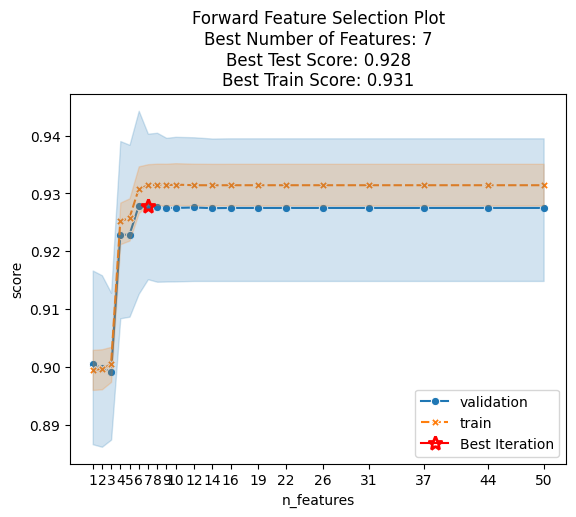

,estimator,LogisticRegre...ndom_state=42)
,step,0.2
,min_features_to_select,None
,max_features_to_select,50
,cv,StratifiedKFo... shuffle=True)
,scoring,'roc_auc'
,verbose,0
,n_jobs,None
,random_state,42
,scheme,'difference'
,n_neighbors,3


In [8]:
from felimination.mrmr import MRMRCV
from felimination.callbacks import plot_progress_callback


selector = MRMRCV(
    model,
    step=0.2,
    max_features_to_select=50,
    callbacks=[plot_progress_callback],
    scoring="roc_auc",
    cv=StratifiedKFold(random_state=42, shuffle=True),
    best_iteration_selection_criteria="mean_test_score",
    random_state=42,
    min_relevance=0.05,
)
selector.fit(X, y)

In [9]:
selector.support_

array([False, False, False, False,  True,  True, False,  True,  True,
       False, False, False, False,  True,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False,  True, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [10]:
selector.ranking_

array([50, 51, 10, 14,  6,  3, 11,  7,  1, 13, 12, 51,  9,  4,  5,  8, 51,
       51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51,
       51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51,
       51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51,
       51, 51, 51, 51, 51, 51, 51,  2, 51, 51, 51, 51, 51, 51, 51, 51, 51,
       51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51,
       51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51,
       51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51,
       51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51,
       51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51,
       51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51,
       51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51])

Notice how model performances increase as more informative features are added, then plateau or drop when only noisy features remain to be selected.

Because MRMR penalises redundant features, the selector tends to pick a diverse set: once a relevant feature is in the selection, correlated copies of it score poorly and are deprioritised in favour of genuinely new signal.

In [11]:
import pandas as pd

cv_results_df = pd.DataFrame(selector.cv_results_)

cv_results_df[["mean_test_score", "n_features"]].sort_values(
    "mean_test_score", ascending=False
).head(10)

,mean_test_score,n_features
6,0.927898,7
5,0.927798,6
7,0.927718,8
10,0.927558,12
12,0.927478,16
18,0.927478,44
17,0.927478,37
16,0.927478,31
15,0.927478,26
14,0.927478,22


The best AUC score obtained with MRMR forward selection is a clear improvement over the baseline.

We can also visualise the full CV curve with the built-in `plot` method, which highlights the best iteration:

<Axes: title={'center': 'Forward Feature Selection Plot\nBest Number of Features: 7\nBest Test Score: 0.928\nBest Train Score: 0.931'}, xlabel='n_features', ylabel='score'>

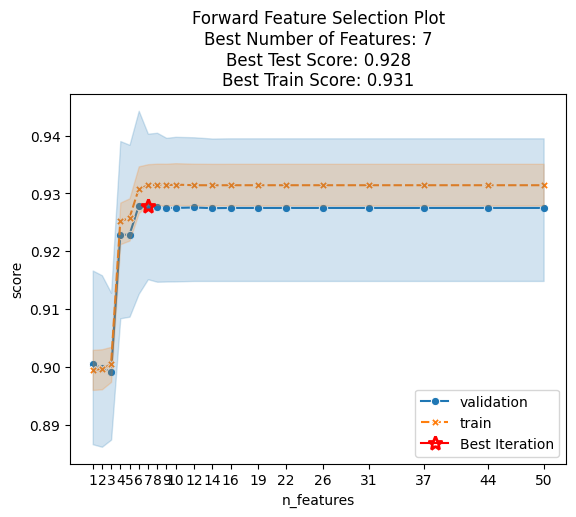

In [12]:
selector.plot()

Looking at the curve, we can decide to pick a slightly smaller subset if the scores are comparable — a smaller model is simpler and generalises better.

We can do this using the method `set_n_features_to_select`. This will change the support of the selector as well as the behaviour of the `transform` method. Note that only values that were evaluated during the forward selection loop are valid choices (i.e. multiples of `step`, starting from 1).

In [13]:
import numpy as np

# Show the index of the selected features — indices 0-5 are informative, 6-15 are redundant, >15 is noise
np.arange(0, X.shape[1])[selector.support_]

array([ 4,  5,  7,  8, 13, 14, 75])

In [14]:
selector.ranking_

array([50, 51, 10, 14,  6,  3, 11,  7,  1, 13, 12, 51,  9,  4,  5,  8, 51,
       51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51,
       51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51,
       51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51,
       51, 51, 51, 51, 51, 51, 51,  2, 51, 51, 51, 51, 51, 51, 51, 51, 51,
       51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51,
       51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51,
       51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51,
       51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51,
       51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51,
       51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51,
       51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51])

In [15]:
import numpy as np
# top 5 Ranking of features with MRMR-CV indices 0-5 are informative, 6-15 are redundant, >15 is noise

np.arange(0, X.shape[1])[np.argsort(selector.ranking_)[:5]]

array([ 8, 75,  5, 13, 14])

We can see that most of the selected features have a low index (informative or redundant region), confirming that MRMR successfully identified the signal-carrying features while ignoring the bulk of random noise.

Because MRMR explicitly penalises redundancy, it also avoids selecting many highly correlated copies from the redundant block — a behaviour that pure relevance-based ranking would not guarantee.